# DHARMa: Simulation-Based Residual Diagnostics for GLMMs

## Overview

Standard residuals are not meaningful for GLMMs, zero-inflated models, or survival models — the residuals don't follow a known reference distribution. **DHARMa** solves this by creating scaled residuals through simulation:

1. Simulate n datasets from the fitted model
2. For each observation, compute the empirical CDF of simulated values
3. The scaled residual = the quantile of the observed value in that CDF

If the model is correctly specified, scaled residuals follow a **uniform distribution on [0,1]** regardless of the error family. This gives a single unified diagnostic framework for any model type.

**What DHARMa detects:**

| Test | What it checks |
|---|---|
| KS test | Overall uniformity of residuals |
| Dispersion test | Over- or under-dispersion |
| Zero-inflation test | More/fewer zeros than expected |
| Outlier test | Extreme observations |
| Residuals vs. predictors | Non-linearity, remaining structure |

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(lme4)          # glmer()
library(glmmTMB)       # glmmTMB() for zero-inflation, NB, etc.
library(DHARMa)        # simulateResiduals(), testDispersion(), etc.
library(patchwork)

set.seed(42)

# ── Simulate: species counts at sites within catchments ───────────────────────
n_catchments <- 15
n_sites_per  <- 12
n_total      <- n_catchments * n_sites_per

dharma_data <- tibble(
  catchment  = rep(1:n_catchments, each=n_sites_per),
  site       = 1:n_total,
  nitrate    = runif(n_total, 1, 10),
  water_qual = runif(n_total, 2, 9),
  offset_area= log(runif(n_total, 0.5, 5))  # log sampling area
) %>%
  mutate(
    catch_re = rep(rnorm(n_catchments, 0, 0.5), each=n_sites_per),
    mu       = exp(2 - 0.3*nitrate + 0.2*water_qual + catch_re + offset_area),
    count    = rnbinom(n_total, mu=mu, size=2)  # overdispersed counts
  )

cat(paste0("n=", n_total, " | Mean count: ", round(mean(dharma_data$count), 1),
           " | % zeros: ", round(mean(dharma_data$count == 0) * 100, 1), "%\n"))

n=180 | Mean count: 14.4 | % zeros: 9.4%


---

## Basic DHARMa Workflow


--- Overdispersion test ---


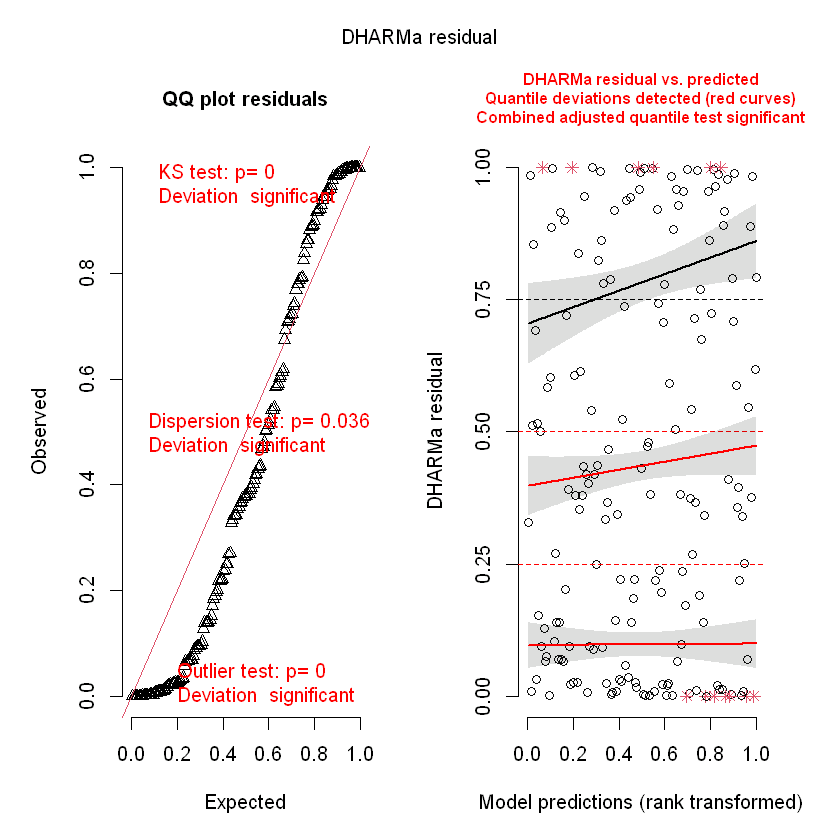


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 2.8596, p-value = 0.036
alternative hypothesis: two.sided



--- Zero-inflation test ---


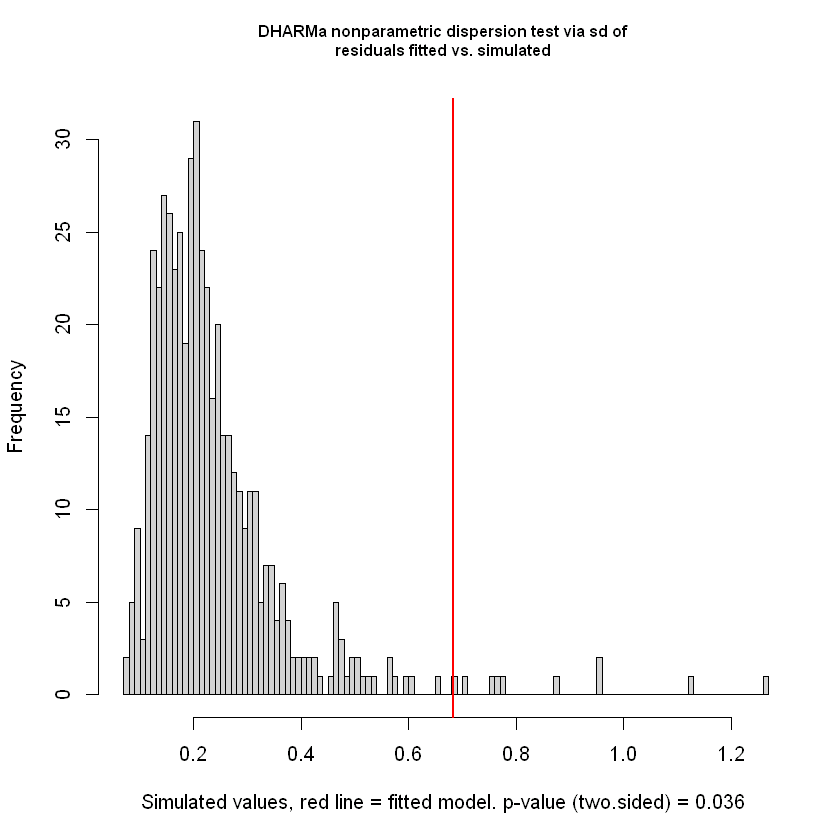


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 3.7264, p-value < 2.2e-16
alternative hypothesis: two.sided


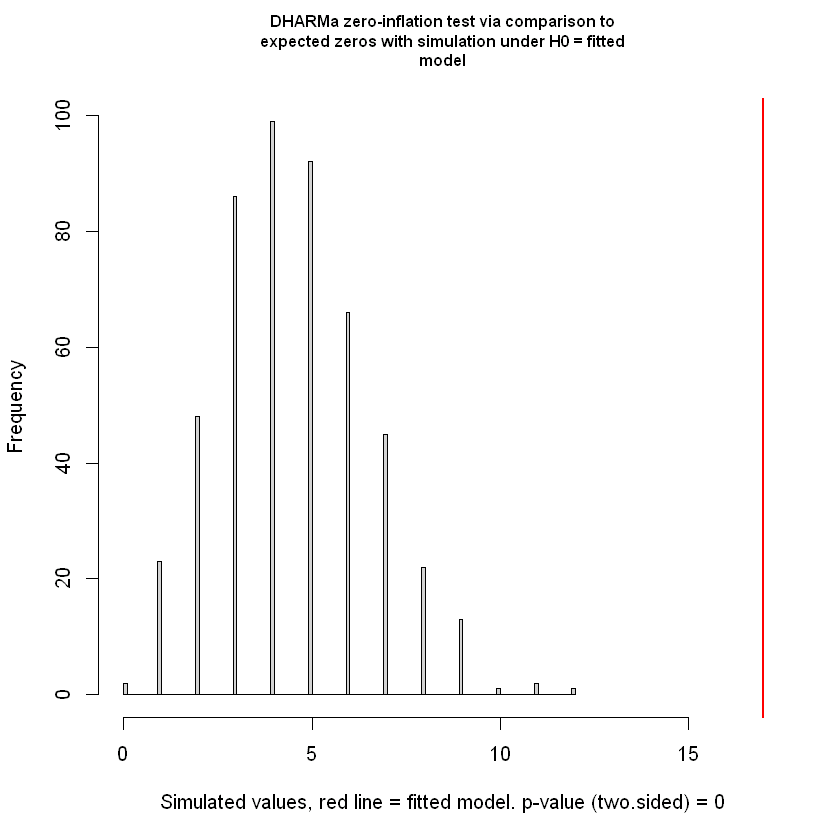

In [4]:
# ── Fit a Poisson GLMM (intentionally misspecified — will show overdispersion) ─
m_poisson <- lme4::glmer(
  count ~ nitrate + water_qual + offset(offset_area) + (1|catchment),
  data   = dharma_data,
  family = poisson
)

# Simulate residuals: n_sim replicates from the fitted model
sim_res_poisson <- DHARMa::simulateResiduals(
  fittedModel = m_poisson,
  n           = 500,     # more = smoother; 250-1000 typical
  plot        = FALSE
)

# ── DHARMa diagnostic plot ────────────────────────────────────────────────────
plot(sim_res_poisson)
# Left panel: QQ plot of scaled residuals vs. uniform
#   Ideal: points on diagonal; KS test p > 0.05
# Right panel: residuals vs. predicted
#   Ideal: no pattern; quantile lines flat at 0.25, 0.50, 0.75

# ── Individual tests ──────────────────────────────────────────────────────────
cat("\n--- Overdispersion test ---\n")
DHARMa::testDispersion(sim_res_poisson)

cat("\n--- Zero-inflation test ---\n")
DHARMa::testZeroInflation(sim_res_poisson)

---

## Fixing the Model: Negative Binomial

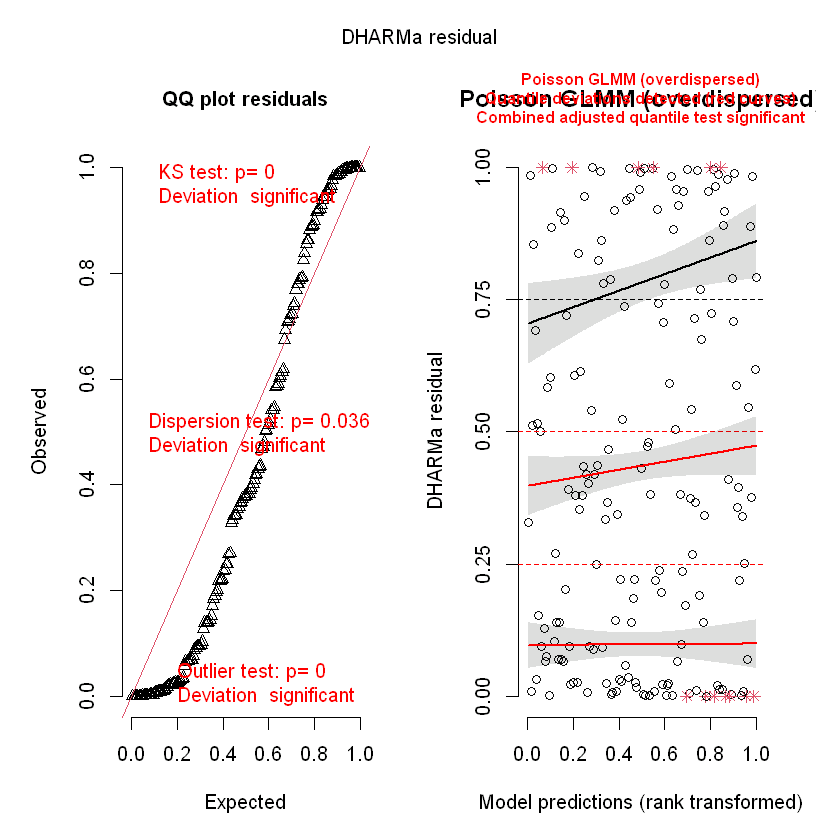


Negative Binomial dispersion test:


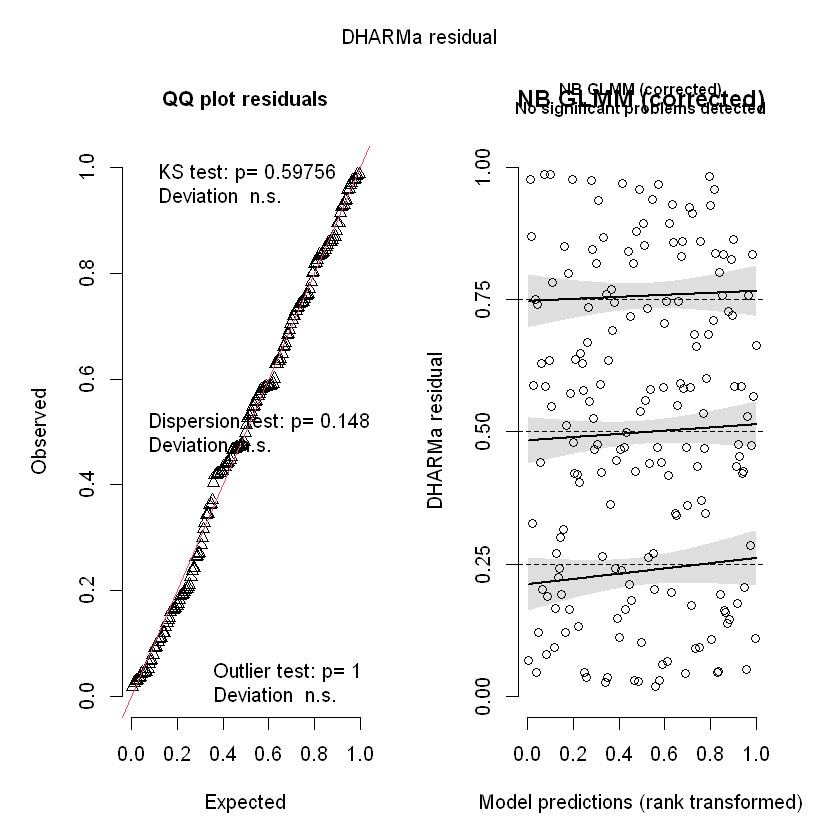


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.48268, p-value = 0.148
alternative hypothesis: two.sided


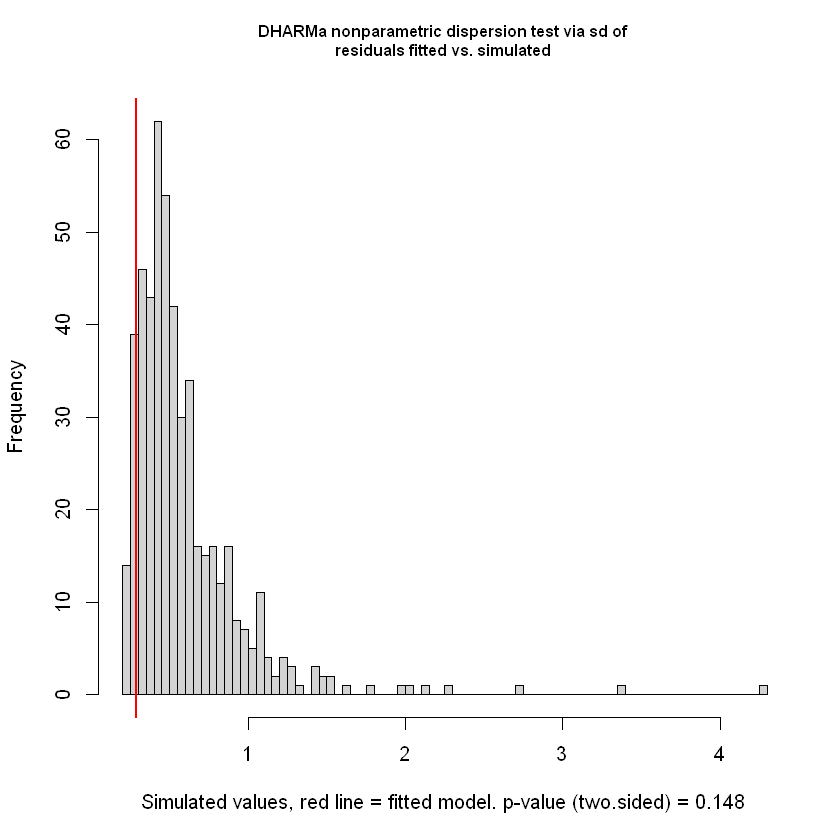

In [5]:
# Negative binomial GLMM addresses overdispersion
m_nb <- glmmTMB::glmmTMB(
  count ~ nitrate + water_qual + offset(offset_area) + (1|catchment),
  data   = dharma_data,
  family = glmmTMB::nbinom2   # NB2: variance = mu + mu²/theta
)

sim_res_nb <- DHARMa::simulateResiduals(m_nb, n=500, plot=FALSE)

# Compare diagnostics
par(mfrow=c(1,2))
plot(sim_res_poisson, main="Poisson GLMM (overdispersed)")
plot(sim_res_nb,      main="NB GLMM (corrected)")
par(mfrow=c(1,1))

# Confirm dispersion is resolved
cat("\nNegative Binomial dispersion test:\n")
DHARMa::testDispersion(sim_res_nb)

---

## Residuals vs. Individual Predictors


Outlier test:


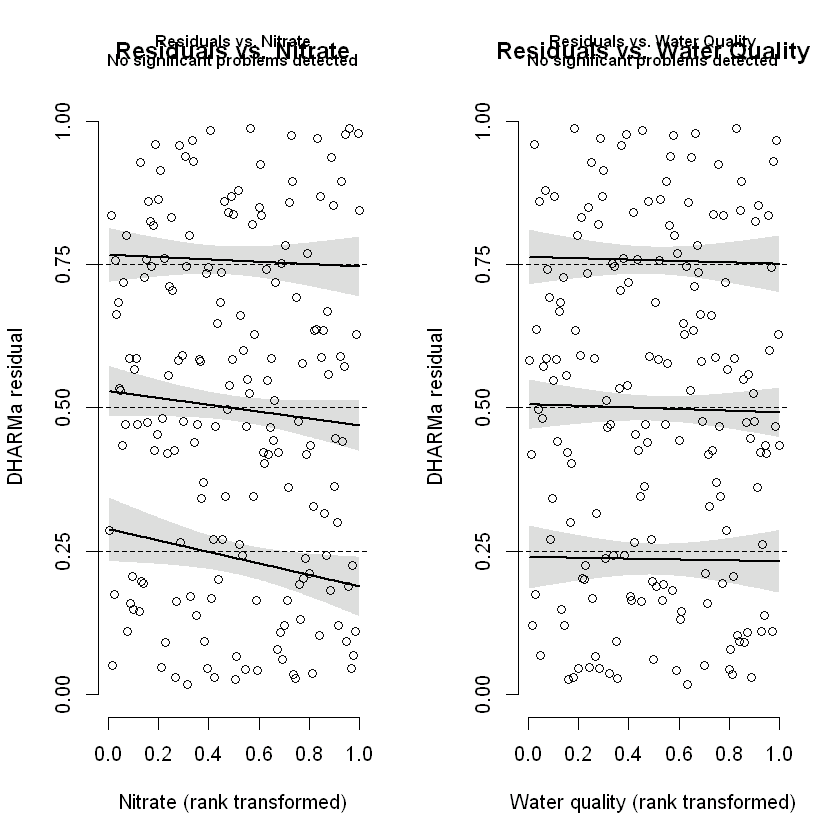


	DHARMa outlier test based on exact binomial test with approximate
	expectations

data:  sim_res_nb
outliers at both margin(s) = 0, observations = 180, p-value = 1
alternative hypothesis: true probability of success is not equal to 0.003992016
95 percent confidence interval:
 0.0000000 0.0202852
sample estimates:
frequency of outliers (expected: 0.00399201596806387 ) 
                                                     0 


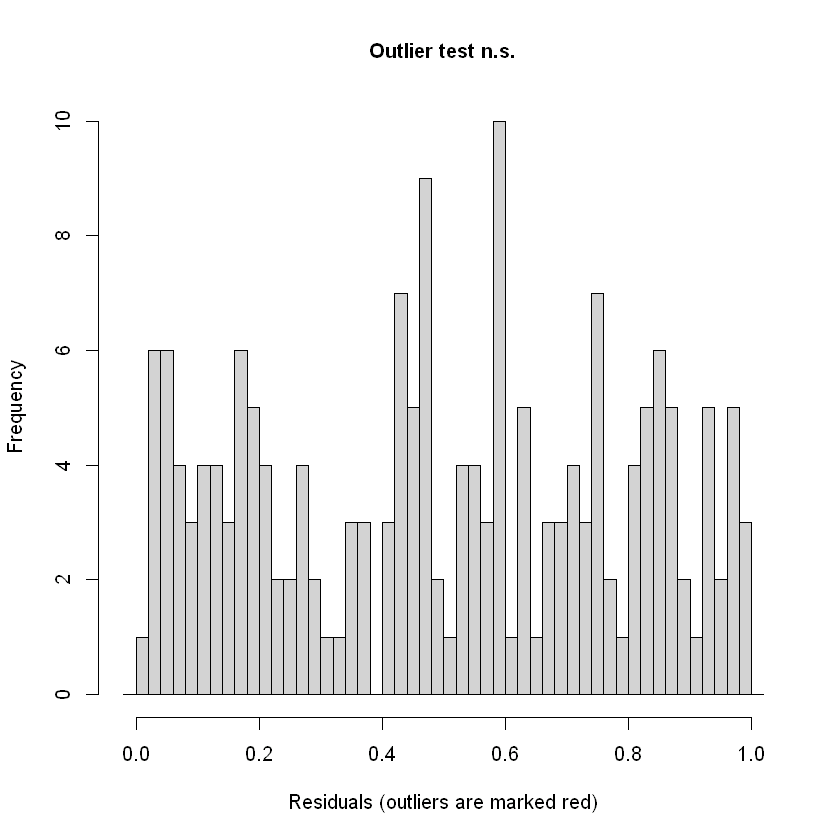

In [6]:
# Check for remaining structure against each predictor
# Non-flat quantile lines indicate non-linearity or missing interaction

par(mfrow=c(1,2))

DHARMa::plotResiduals(
  sim_res_nb,
  form = dharma_data$nitrate,
  main = "Residuals vs. Nitrate",
  xlab = "Nitrate"
)

DHARMa::plotResiduals(
  sim_res_nb,
  form = dharma_data$water_qual,
  main = "Residuals vs. Water Quality",
  xlab = "Water quality"
)

par(mfrow=c(1,1))

# Temporal / spatial autocorrelation test
# Requires observed and expected correlogram
cat("\nOutlier test:\n")
DHARMa::testOutliers(sim_res_nb, type="binomial")

---

## Common Pitfalls

**1. Using raw residuals from GLMMs for normality checks**  
Raw residuals from a Poisson GLMM are not expected to be normally distributed — that is a property of the Gaussian family only. Applying `shapiro.test()` or a Q-Q plot to raw GLMM residuals is meaningless. Always use DHARMa's simulation-based scaled residuals, which are uniform under correct specification regardless of the error family.

**2. Using too few simulations (n_sim)**  
With only 50–100 simulations, the empirical CDF is noisy and the KS test has low power. Use at least n=250; n=500–1000 for publication-quality diagnostics. The test statistics stabilise around n=500.

**3. Ignoring the residuals-vs-predictor plots after fixing dispersion**  
Correcting overdispersion with a negative binomial often resolves the QQ plot, but residual structure against predictors (non-linearity, threshold effects) can remain. Always check `plotResiduals()` against each covariate after fitting the corrected model.

**4. Concluding the model is correct because DHARMa tests are non-significant**  
Non-significant DHARMa tests mean no detected violations — not that the model is correctly specified. Model correctness depends on structural assumptions (right covariates, right link function, correct random effects structure) that DHARMa cannot evaluate. Use DHARMa alongside AIC comparison and domain knowledge.

**5. Not re-running DHARMa after changing the random effects structure**  
Over- or under-specified random effects (e.g. missing a grouping level, or an unnecessary slope term) can appear as residual structure in DHARMa output. After any change to the random effects structure — adding a crossed effect, switching from (1|site) to (1+nitrate|site) — rerun the full DHARMa diagnostic suite.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*